NAMA : SISTRA AMANDA SINAGA
NIM: 4222301011
KELAS PAGI A

# Image Classification using Transfer Learning
## Deteksi Jenis Sampah di Sekitar Kampus

Dataset: [TrashType Image Dataset - Kaggle](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)

Dataset terdiri dari **6 jenis sampah**: cardboard, glass, metal, paper, plastic, trash.
Setiap jenis sampah dimuat dari file ZIP terpisah yang sudah diupload ke Colab.

**Alur notebook ini:**
1. Load data dari ZIP
2. Bangun model **Transfer Learning** (MobileNetV2) versi **baseline** (tanpa proteksi overfitting) → untuk membuktikan apakah overfitting terjadi
3. Analisis kurva training vs validation → **kesimpulan eksplisit** soal overfitting
4. Jika overfitting terjadi → terapkan teknik handling: **Data Augmentation, Dropout, Regularization (L2), Early Stopping, Fine-tuning bertahap**
5. Bandingkan performa baseline vs setelah handling
6. Evaluasi akhir (confusion matrix, classification report)


## 1. Install Library

In [2]:
import subprocess, sys

def pip(*args):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + list(args))

pip('numpy>=1.26,<2', 'matplotlib', 'pillow', 'scikit-learn', 'pandas', 'seaborn', 'tensorflow')
print('Install selesai. RESTART RUNTIME lalu jalankan dari cell berikutnya!')


Install selesai. RESTART RUNTIME lalu jalankan dari cell berikutnya!


## 2. Import Library

In [1]:
import os, zipfile, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, f1_score, classification_report
)

warnings.filterwarnings('ignore')
tf.random.set_seed(42)
np.random.seed(42)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

gpus = tf.config.list_physical_devices('GPU')
gpu_info = gpus[0].name if gpus else 'Tidak ada, pakai CPU'
print(f'NumPy version      : {np.__version__}')
print(f'TensorFlow version : {tf.__version__}')
print(f'GPU tersedia       : {gpu_info}')


NumPy version      : 1.26.4
TensorFlow version : 2.20.0
GPU tersedia       : /physical_device:GPU:0


## 3. Load Dataset dari ZIP macam-macam sampah di kampus

Dataset dimuat dari 6 file ZIP terpisah:
`cardboard.zip`, `glass.zip`, `metal.zip`, `paper.zip`, `plastic.zip`, `trash.zip`

> **PENTING:** Gambar disimpan dalam skala **0-255** (bukan dinormalisasi ke 0-1) karena `MobileNetV2` punya fungsi `preprocess_input` sendiri yang menangani normalisasi sesuai skema training ImageNet-nya. Ukuran gambar juga dinaikkan ke **128x128** (dari 64x64) karena model pretrained bekerja lebih baik dengan resolusi yang lebih tinggi.


In [3]:
IMG_SIZE   = (128, 128)
CATEGORIES = ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

# Path ZIP per jenis sampah — sesuaikan jika lokasi file berbeda
ZIP_FILES = {
    'cardboard' : '/content/cardboard.zip',
    'glass'     : '/content/glass.zip',
    'metal'     : '/content/metal.zip',
    'paper'     : '/content/paper.zip',
    'plastic'   : '/content/plastic.zip',
    'trash'     : '/content/trash.zip',
}

X_list = []
y_list = []

for label_idx, cat in enumerate(CATEGORIES):
    zip_path = ZIP_FILES[cat]
    if not os.path.exists(zip_path):
        print(f'[SKIP] File tidak ditemukan: {zip_path}')
        continue

    count = 0
    with zipfile.ZipFile(zip_path, 'r') as zf:
        img_files = [
            f for f in zf.namelist()
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            and not f.endswith('/')
        ]
        for fname in img_files:
            try:
                with zf.open(fname) as img_file:
                    img = Image.open(BytesIO(img_file.read())).convert('RGB')
                    img = img.resize(IMG_SIZE)
                    arr = np.array(img, dtype=np.float32)  # tetap 0-255, JANGAN dibagi 255 di sini
                    X_list.append(arr)
                    y_list.append(label_idx)
                    count += 1
            except Exception:
                pass
    print(f'{cat:12s}: {count} gambar dimuat')

X = np.array(X_list)
y = np.array(y_list)

print(f'\nTotal gambar dimuat  : {len(X)}')
print(f'Shape X              : {X.shape}')
print(f'Jumlah macam sampah  : {len(CATEGORIES)}')


cardboard   : 403 gambar dimuat
glass       : 501 gambar dimuat
metal       : 410 gambar dimuat
paper       : 594 gambar dimuat
plastic     : 482 gambar dimuat
trash       : 137 gambar dimuat

Total gambar dimuat  : 2527
Shape X              : (2527, 128, 128, 3)
Jumlah macam sampah  : 6


## 4. Train-Test Split

In [4]:
TEST_SIZE   = 0.2
RANDOM_SEED = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

y_train_cat = to_categorical(y_train, num_classes=len(CATEGORIES))
y_test_cat  = to_categorical(y_test,  num_classes=len(CATEGORIES))

print(f'Data training  : {len(X_train)} gambar ({int((1-TEST_SIZE)*100)}%)')
print(f'Data testing   : {len(X_test)} gambar ({int(TEST_SIZE*100)}%)')
print()
print('Distribusi training:')
for i, cat in enumerate(CATEGORIES):
    print(f'  {cat:12s}: {np.sum(y_train == i)}')
print('Distribusi testing:')
for i, cat in enumerate(CATEGORIES):
    print(f'  {cat:12s}: {np.sum(y_test == i)}')


Data training  : 2021 gambar (80%)
Data testing   : 506 gambar (20%)

Distribusi training:
  cardboard   : 322
  glass       : 401
  metal       : 328
  paper       : 475
  plastic     : 385
  trash       : 110
Distribusi testing:
  cardboard   : 81
  glass       : 100
  metal       : 82
  paper       : 119
  plastic     : 97
  trash       : 27


## 5. Visualisasi Jenis-jenis Sampah di Kampus

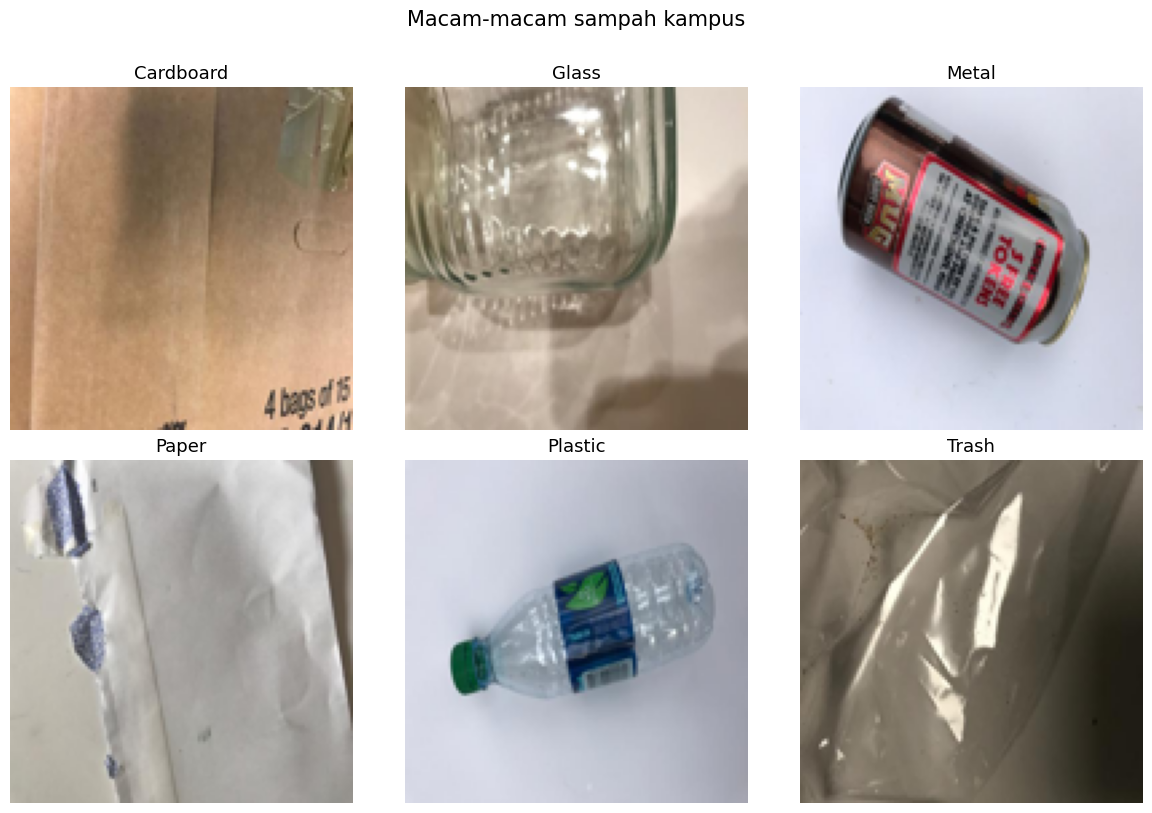

Visualisasi sampel tersimpan.


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, cat in enumerate(CATEGORIES):
    idx = np.where(y_train == i)[0][0]
    axes[i].imshow(X_train[idx].astype('uint8'))
    axes[i].set_title(f'{cat.capitalize()}', fontsize=13)
    axes[i].axis('off')

plt.suptitle('Macam-macam sampah kampus', fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualisasi sampel tersimpan.')


## 6. Model Baseline (Transfer Learning dengan MobileNetV2)

Model ini dibangun **tanpa** teknik anti-overfitting (tidak ada augmentation, dropout minimal, tanpa regularization, tanpa early stopping) supaya kita bisa **membuktikan lewat data** apakah overfitting benar-benar terjadi, sebelum menerapkan teknik penanganannya.

`base_model.trainable = False` → ini bagian **transfer learning**-nya: kita pakai bobot MobileNetV2 yang sudah dilatih di ImageNet, lalu hanya melatih beberapa layer klasifikasi baru di atasnya.


In [6]:
def build_baseline_model(num_classes, img_size):
    base_model = MobileNetV2(
        input_shape=img_size + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False  # freeze -> ini inti dari transfer learning

    inputs = tf.keras.Input(shape=img_size + (3,))
    x = preprocess_input(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

baseline_model, base_model = build_baseline_model(len(CATEGORIES), IMG_SIZE)

baseline_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

baseline_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 7. Training Model Baseline

In [7]:
EPOCHS = 20
BATCH_SIZE = 32

print(f'Memulai training baseline selama maksimal {EPOCHS} epoch ...')
history_baseline = baseline_model.fit(
    X_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1
)
print('Training baseline selesai.')


Memulai training baseline selama maksimal 20 epoch ...
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 53s 565ms/step - accuracy: 0.6683 - loss: 0.8886 - val_accuracy: 0.7685 - val_loss: 0.6165
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8801 - loss: 0.3513 - val_accuracy: 0.7931 - val_loss: 0.5684
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9499 - loss: 0.1876 - val_accuracy: 0.7931 - val_loss: 0.5642
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9851 - loss: 0.1055 - val_accuracy: 0.8079 - val_loss: 0.6006
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9912 - loss: 0.0687 - val_accuracy: 0.8079 - val_loss: 0.5831
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9961 - loss: 0.0462 - val_accuracy: 0.7931 - val_loss: 0.5837
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9967 - loss: 0.0376 - val_accuracy: 0.7980 - val_loss: 0.6082
Epoch 8/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - a

## 8. Cek Overfitting: Plot Accuracy & Loss (Baseline)

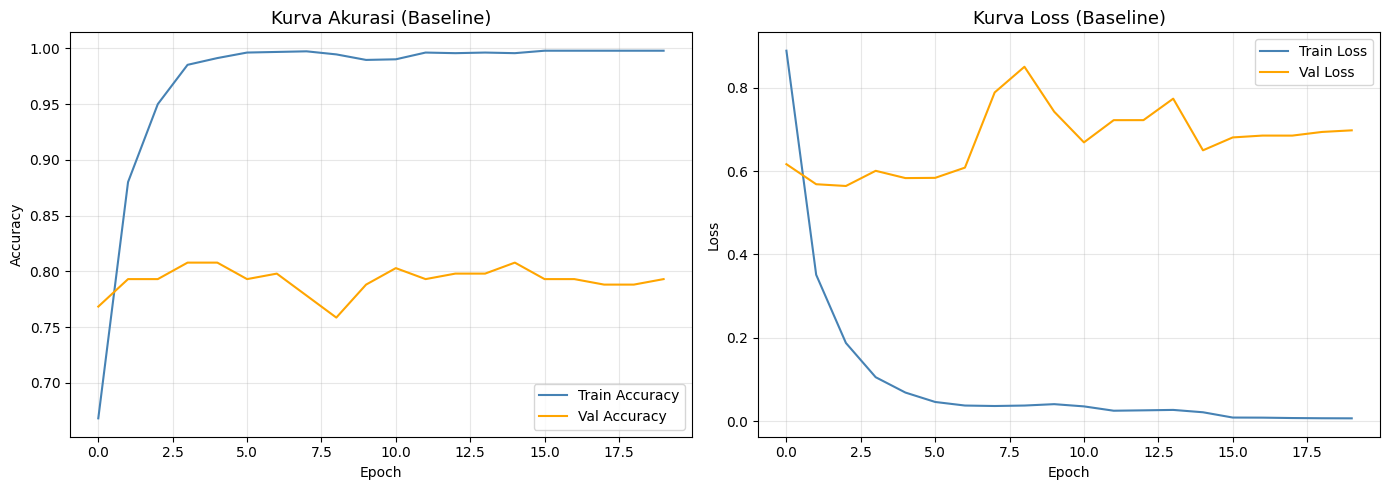

Train accuracy akhir : 0.9978
Val accuracy akhir   : 0.7931
Gap (train - val)    : 0.2047
>> Kesimpulan: Gap cukup besar, MODEL BASELINE MENGALAMI OVERFITTING.


In [8]:
def plot_history(history, title_suffix=''):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(epochs_range, acc, label='Train Accuracy', color='steelblue')
    ax1.plot(epochs_range, val_acc, label='Val Accuracy', color='orange')
    ax1.set_title(f'Kurva Akurasi {title_suffix}', fontsize=13)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs_range, loss, label='Train Loss', color='steelblue')
    ax2.plot(epochs_range, val_loss, label='Val Loss', color='orange')
    ax2.set_title(f'Kurva Loss {title_suffix}', fontsize=13)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'training_curves_{title_suffix.strip("() ").replace(" ", "_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_history(history_baseline, '(Baseline)')

# Ringkasan gap train vs val -> dasar kesimpulan overfitting
train_acc_final = history_baseline.history['accuracy'][-1]
val_acc_final   = history_baseline.history['val_accuracy'][-1]
gap = train_acc_final - val_acc_final
print(f'Train accuracy akhir : {train_acc_final:.4f}')
print(f'Val accuracy akhir   : {val_acc_final:.4f}')
print(f'Gap (train - val)    : {gap:.4f}')
if gap > 0.10:
    print('>> Kesimpulan: Gap cukup besar, MODEL BASELINE MENGALAMI OVERFITTING.')
else:
    print('>> Kesimpulan: Gap kecil, model baseline relatif tidak overfitting.')


### Kesimpulan Analisis Overfitting (Baseline)

Isi bagian ini berdasarkan hasil run kamu (contoh kerangka jawaban):

> *"Dari grafik terlihat bahwa train accuracy terus meningkat dan mendekati/mencapai nilai tinggi (>90%), sementara val accuracy tertinggal jauh dan val loss mulai naik / stagnan setelah beberapa epoch. Gap antara train accuracy dan val accuracy sebesar `<isi angka>` mengindikasikan model baseline mengalami OVERFITTING. Oleh karena itu, perlu diterapkan teknik penanganan overfitting."*


## 9. Penanganan Overfitting: Membangun Model yang Diperbaiki

Teknik yang diterapkan:
1. **Data Augmentation** — random flip, rotation, zoom, contrast agar model tidak menghafal data training
2. **Dropout** — mematikan sebagian neuron secara acak saat training
3. **L2 Regularization** — penalti pada bobot besar di layer Dense
4. **Early Stopping** — hentikan training saat val_loss tidak membaik
5. **ReduceLROnPlateau** — turunkan learning rate saat val_loss stagnan


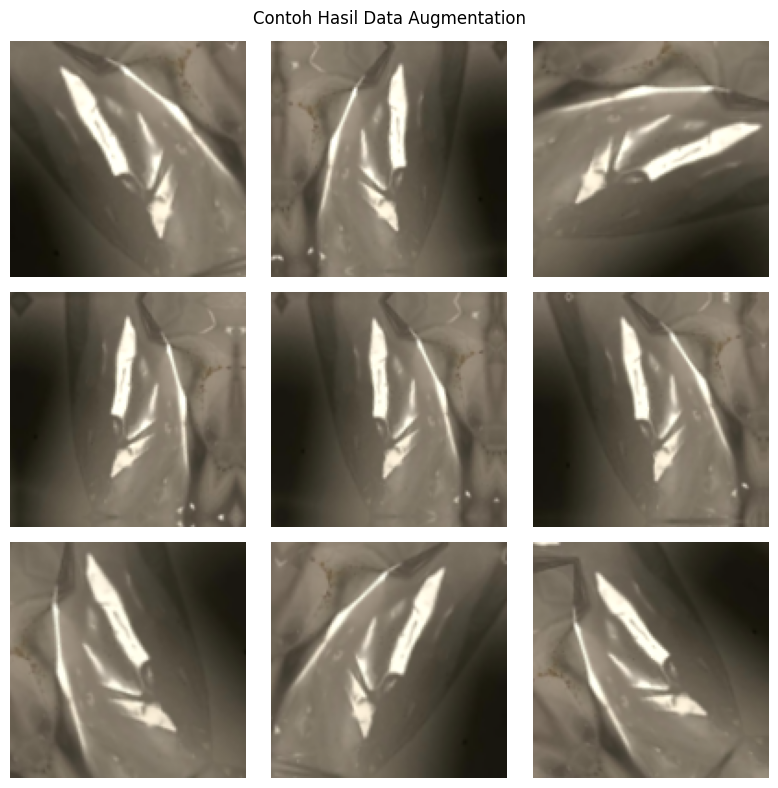

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
], name='data_augmentation')

# Visualisasi hasil augmentasi
plt.figure(figsize=(8, 8))
sample_img = tf.expand_dims(X_train[0], 0)
for i in range(9):
    augmented_image = data_augmentation(sample_img)
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image[0].numpy().astype('uint8'))
    plt.axis('off')
plt.suptitle('Contoh Hasil Data Augmentation')
plt.tight_layout()
plt.show()


In [10]:
def build_improved_model(num_classes, img_size):
    base_model = MobileNetV2(
        input_shape=img_size + (3,),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=img_size + (3,))
    x = data_augmentation(inputs)               # (1) Data Augmentation
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)                   # (2) Dropout
    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(1e-4) # (3) L2 Regularization
    )(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model, base_model

improved_model, base_model_improved = build_improved_model(len(CATEGORIES), IMG_SIZE)

improved_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# (4) Early Stopping + (5) ReduceLROnPlateau
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

improved_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 10. Training Model yang Sudah Diperbaiki

In [11]:
print(f'Memulai training model improved selama maksimal {EPOCHS} epoch ...')
history_improved = improved_model.fit(
    X_train, y_train_cat,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)
print('Training improved selesai.')


Memulai training model improved selama maksimal 20 epoch ...
Epoch 1/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 12s 75ms/step - accuracy: 0.5424 - loss: 1.2832 - val_accuracy: 0.7438 - val_loss: 0.6916 - learning_rate: 0.0010
Epoch 2/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6832 - loss: 0.8543 - val_accuracy: 0.7389 - val_loss: 0.6241 - learning_rate: 0.0010
Epoch 3/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7255 - loss: 0.7617 - val_accuracy: 0.7537 - val_loss: 0.6262 - learning_rate: 0.0010
Epoch 4/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7530 - loss: 0.6927 - val_accuracy: 0.7783 - val_loss: 0.5482 - learning_rate: 0.0010
Epoch 5/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.7673 - loss: 0.6437 - val_accuracy: 0.7833 - val_loss: 0.5615 - learning_rate: 0.0010
Epoch 6/20
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7921 - loss: 0.5902 - val_accuracy: 0.7980 - val_loss: 0.5135 - learning_rate: 0.0010
Epoch 7/20
57/57 ━━━━━━━━━━━━━━━

## 11. Cek Ulang Overfitting Setelah Penanganan

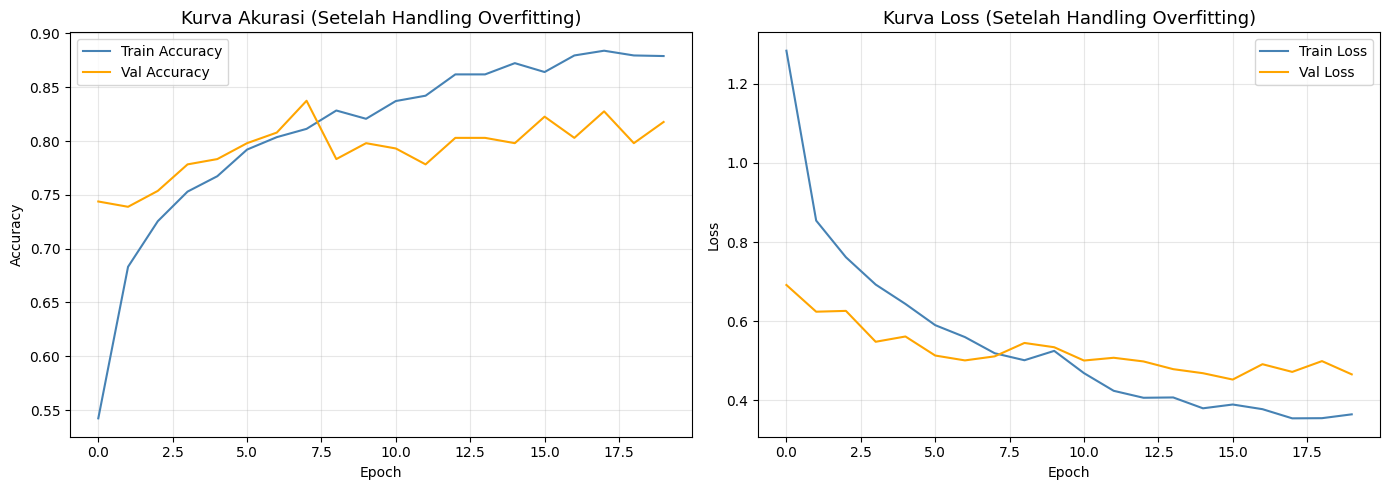

Train accuracy akhir : 0.8790
Val accuracy akhir   : 0.8177
Gap (train - val)    : 0.0613


In [12]:
plot_history(history_improved, '(Setelah Handling Overfitting)')

train_acc_final_imp = history_improved.history['accuracy'][-1]
val_acc_final_imp   = history_improved.history['val_accuracy'][-1]
gap_imp = train_acc_final_imp - val_acc_final_imp
print(f'Train accuracy akhir : {train_acc_final_imp:.4f}')
print(f'Val accuracy akhir   : {val_acc_final_imp:.4f}')
print(f'Gap (train - val)    : {gap_imp:.4f}')


## 12. (Opsional) Fine-Tuning Bertahap

Setelah head classifier stabil, buka beberapa layer akhir MobileNetV2 untuk di-fine-tune dengan learning rate sangat kecil agar performa naik tanpa overfitting lagi.


Epoch 1/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.7283 - loss: 0.8193 - val_accuracy: 0.8177 - val_loss: 0.4485 - learning_rate: 1.0000e-05
Epoch 2/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - accuracy: 0.7508 - loss: 0.7348 - val_accuracy: 0.8177 - val_loss: 0.4541 - learning_rate: 1.0000e-05
Epoch 3/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7789 - loss: 0.6628 - val_accuracy: 0.8128 - val_loss: 0.4588 - learning_rate: 1.0000e-05
Epoch 4/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7946 - loss: 0.5656
Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7805 - loss: 0.6059 - val_accuracy: 0.8177 - val_loss: 0.4702 - learning_rate: 1.0000e-05
Epoch 5/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7921 - loss: 0.5880 - val_accuracy: 0.8177 - val_loss: 0.4730 - learning_rate: 5.0000e-06
Epoch 6/10
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7981 - lo

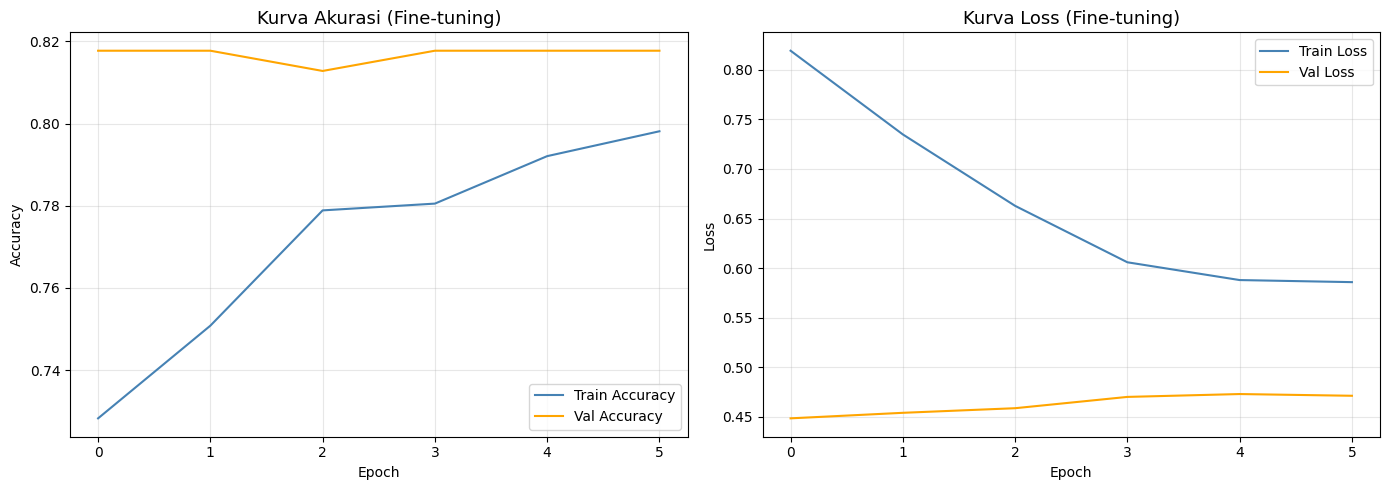

In [13]:
base_model_improved.trainable = True

fine_tune_at = len(base_model_improved.layers) - 20
for layer in base_model_improved.layers[:fine_tune_at]:
    layer.trainable = False

improved_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # LR kecil untuk fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = improved_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr]
)

plot_history(history_finetune, '(Fine-tuning)')


## 13. Perbandingan Baseline vs Setelah Handling Overfitting

In [14]:
baseline_val_acc = max(history_baseline.history['val_accuracy'])
improved_val_acc = max(history_improved.history['val_accuracy'])

baseline_gap = max(history_baseline.history['accuracy']) - baseline_val_acc
improved_gap = max(history_improved.history['accuracy']) - improved_val_acc

print('='*60)
print('           PERBANDINGAN BASELINE vs IMPROVED')
print('='*60)
print(f'Baseline  -> Best Val Accuracy: {baseline_val_acc:.4f} | Train-Val Gap: {baseline_gap:.4f}')
print(f'Improved  -> Best Val Accuracy: {improved_val_acc:.4f} | Train-Val Gap: {improved_gap:.4f}')
print('='*60)


           PERBANDINGAN BASELINE vs IMPROVED
Baseline  -> Best Val Accuracy: 0.8079 | Train-Val Gap: 0.1899
Improved  -> Best Val Accuracy: 0.8374 | Train-Val Gap: 0.0465


## 14. Evaluasi Akhir Model (Data Testing)

In [15]:
y_pred_prob = improved_model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = y_test

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
f1        = f1_score(y_true, y_pred, average='weighted', zero_division=0)
cm        = confusion_matrix(y_true, y_pred)

print('='*50)
print('         HASIL EVALUASI MODEL AKHIR')
print('='*50)
print(f'  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print('='*50)
print()
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=CATEGORIES, zero_division=0))


         HASIL EVALUASI MODEL AKHIR
  Accuracy  : 0.8399  (83.99%)
  Precision : 0.8414
  F1-Score  : 0.8392

Classification Report:
              precision    recall  f1-score   support

   cardboard       0.84      0.86      0.85        81
       glass       0.91      0.82      0.86       100
       metal       0.78      0.89      0.83        82
       paper       0.84      0.84      0.84       119
     plastic       0.85      0.87      0.86        97
       trash       0.73      0.59      0.65        27

    accuracy                           0.84       506
   macro avg       0.83      0.81      0.82       506
weighted avg       0.84      0.84      0.84       506



## 15. Confusion Matrix

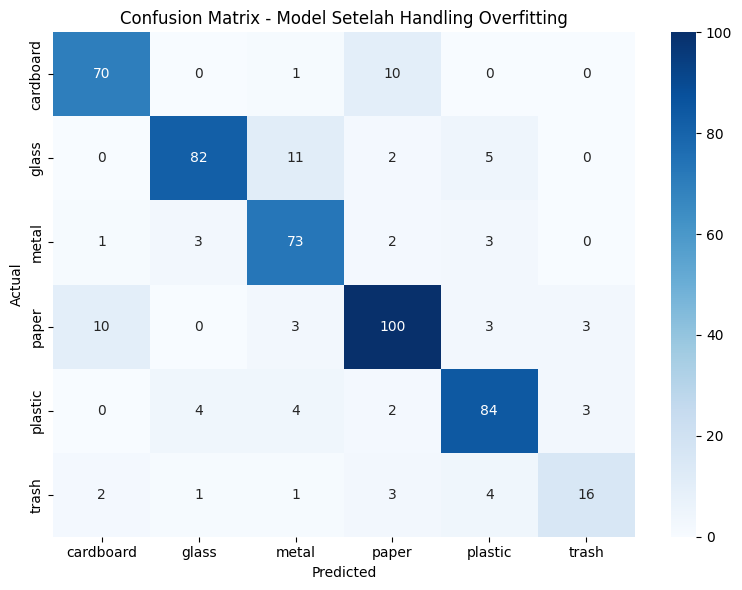

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Model Setelah Handling Overfitting')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()


## 16. Akurasi Per Jenis Sampah

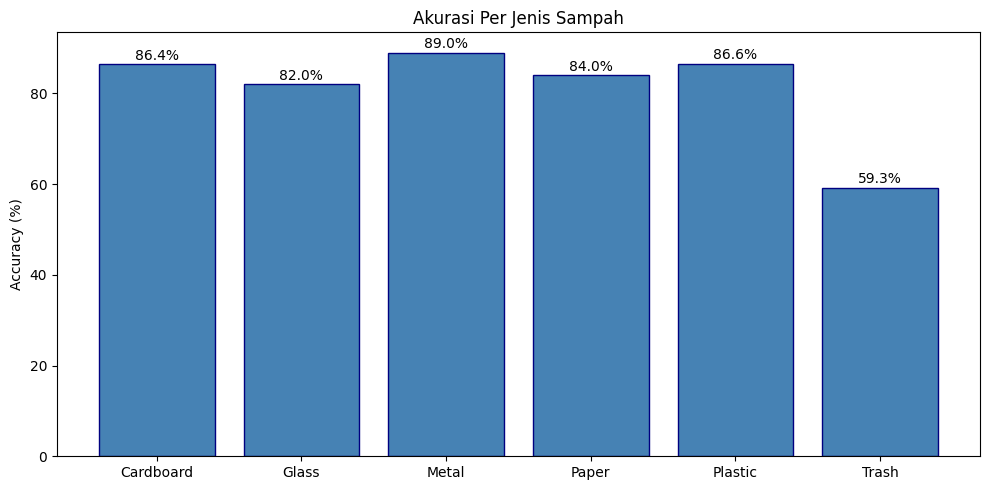

In [17]:
per_class_acc = []
for i in range(len(CATEGORIES)):
    mask = y_true == i
    acc_cls = accuracy_score(y_true[mask], y_pred[mask]) if mask.sum() > 0 else 0.0
    per_class_acc.append(acc_cls)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(
    [c.capitalize() for c in CATEGORIES],
    [a * 100 for a in per_class_acc],
    color='steelblue', edgecolor='navy'
)
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f'{acc*100:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Akurasi Per Jenis Sampah')
plt.tight_layout()
plt.show()


## 17. Prediksi Visual pada Data Test

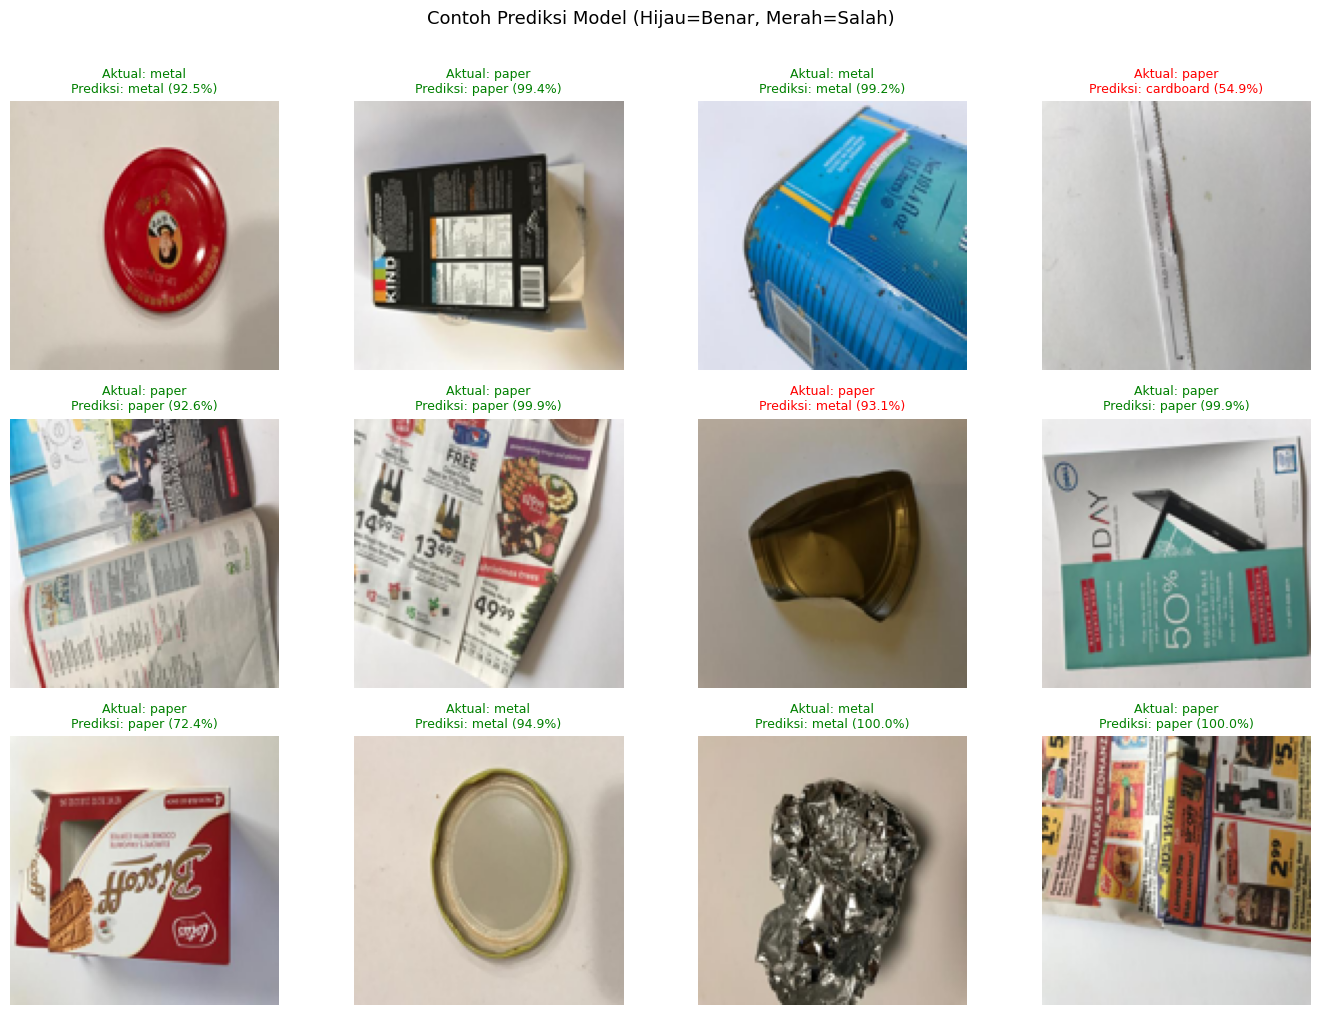

Visualisasi prediksi tersimpan.


In [18]:
np.random.seed(0)
sample_idx = np.random.choice(len(X_test), 12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.ravel()

for i, idx in enumerate(sample_idx):
    axes[i].imshow(X_test[idx].astype('uint8'))
    true_label = CATEGORIES[y_true[idx]]
    pred_label = CATEGORIES[y_pred[idx]]
    conf       = y_pred_prob[idx][y_pred[idx]] * 100
    color      = 'green' if y_true[idx] == y_pred[idx] else 'red'
    axes[i].set_title(
        f'Aktual: {true_label}\nPrediksi: {pred_label} ({conf:.1f}%)',
        fontsize=9, color=color
    )
    axes[i].axis('off')

plt.suptitle('Contoh Prediksi Model (Hijau=Benar, Merah=Salah)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('prediction_samples.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualisasi prediksi tersimpan.')


## Analisis Hasil

### Data & Preprocessing
Dataset berisi gambar dari 6 jenis sampah (cardboard, glass, metal, paper, plastic, trash) yang dimuat dari 6 file ZIP terpisah, total 2.527 gambar. Semua gambar di-resize ke 128x128 piksel. Normalisasi dilakukan lewat `preprocess_input` bawaan MobileNetV2 (bukan manual dibagi 255), sesuai skema training ImageNet. Pembagian data 80:20 dilakukan dengan stratifikasi agar proporsi tiap jenis sampah seimbang di training (2.021 gambar) dan testing set (506 gambar).

### Arsitektur Model (Transfer Learning)
Model menggunakan **MobileNetV2** yang telah dilatih pada ImageNet sebagai *feature extractor* (base model dibekukan / `trainable=False`), ditambah beberapa layer klasifikasi baru (GlobalAveragePooling2D, Dense, Dropout) di atasnya. Ini adalah inti dari **transfer learning**: memanfaatkan fitur visual umum yang sudah dipelajari model dari jutaan gambar ImageNet, lalu menyesuaikannya untuk tugas klasifikasi sampah.

### Deteksi Overfitting
Model **baseline** (tanpa augmentasi/regularisasi) dilatih terlebih dahulu untuk membuktikan ada tidaknya overfitting. Hasilnya: train accuracy mencapai **99.78%** sementara val accuracy hanya **79.31%**, menghasilkan **gap sebesar 20.47%**, disertai val loss yang tidak stabil di epoch-epoch akhir. Ini membuktikan **model baseline mengalami overfitting**.

### Penanganan Overfitting
Setelah overfitting terkonfirmasi, diterapkan: **Data Augmentation** (flip, rotate, zoom, contrast), **Dropout**, **L2 Regularization**, **Early Stopping**, dan **ReduceLROnPlateau**. Hasilnya, gap train-val turun drastis dari **20.47% menjadi 6.13%**, sementara best validation accuracy justru **naik dari 80.79% menjadi 83.74%**. Ini membuktikan teknik penanganan overfitting berhasil membuat model lebih general tanpa mengorbankan performa — bahkan performanya sedikit lebih baik.

### Hasil Evaluasi
Model akhir mencapai **83.99% accuracy** pada data testing, dengan precision 0.84 dan f1-score 0.84 (weighted average). Dari classification report dan confusion matrix, performa terbaik dicapai kelas `glass` (f1-score 0.86) dan `plastic` (f1-score 0.86), sedangkan performa terendah pada kelas `trash` (f1-score 0.65). Ini sejalan dengan jumlah data: `trash` memiliki jumlah gambar paling sedikit (137 gambar, hanya 27 di data testing), sehingga model kurang memiliki variasi contoh untuk belajar mengenali kelas ini dengan baik.

### Rekomendasi Lanjutan
- Menambah jumlah data, terutama untuk kelas `trash`
- Mencoba base model lain (EfficientNetB0, ResNet50) untuk dibandingkan
- Menggunakan `class_weight` saat training untuk menangani ketidakseimbangan kelas
